# Algorytm Chan'a

Załadowanie potrzebnych struktur oraz testów

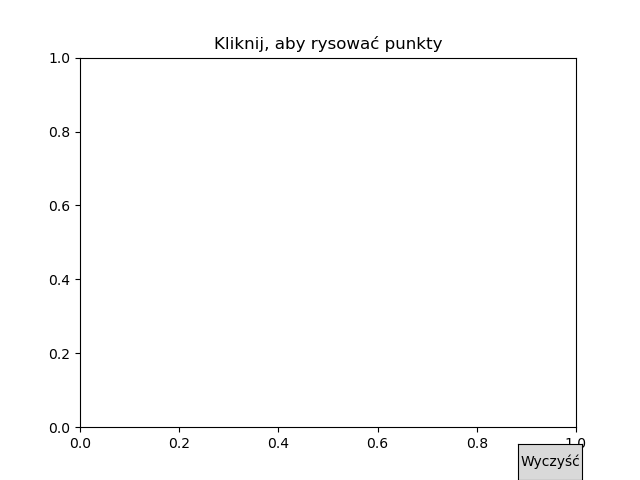

In [2]:
import sys
import io

# Procedura do niewypisywania zbędnych infomracji z innych plików
original_stdout = sys.stdout

sys.stdout = io.StringIO()

%run interface.ipynb
%run tests.ipynb
%run graham.ipynb
import math

sys.stdout = original_stdout

### Algorytm Chan'a - wersja bez wizualizacji algorytmu

In [3]:
def det(a, b, c):
    return a.x * b.y + b.x * c.y + a.y * c.x - c.x * b.y - b.x * a.y - a.x * c.y

In [4]:
def orient(a, b, c):
    # Określa orientację punktów (a, b, c)
    result = det(a, b, c)
    
    if result > 10e-12:
        return 1  # Przeciwnie do ruchu wskazówek zegara
    elif result < -10e-12:
        return -1 # Zgodnie z ruchem wskazówek zegara
    else:
        return 0  # Współliniowe

In [5]:
def divide_all_points(points, m):
    n = len(points)
    r = math.ceil(n / m)
    l = n // m # tyle będzie grup liczących m punktów
    k = n % m # tyle punktów będzie w ostatniej grupie
    new_groups = [[] for _ in range(r)]

    for i in range(l):
        for j in range(m):
            new_groups[i].append(points[i * m + j])

    for i in range(k):
        new_groups[-1].append(points[l * m + i])

    return new_groups

In [6]:
def find_lowest_point(hulls):
    min_y_point = hulls[0][0] # aktualny najmniejszy punkt
    k, l = 0, 0 # indeks otoczki oraz punktu w otoczce
    for i in range(len(hulls)):
        for j in range(len(hulls[i])):
            if hulls[i][j].y < min_y_point.y or (hulls[i][j].y == min_y_point.y and hulls[i][j].x < min_y_point.x):
                min_y_point = hulls[i][j]
                k, l = i, j
    
    return k, l

In [7]:
def points_distance(point1, point2):
    x_delta = point2.x - point1.x
    y_delta = point2.y - point1.y
    return x_delta**2 + y_delta**2

In [8]:
def find_next_point_in_hull(hull, point):
    n = len(hull)
    l, r = 0, n - 1
    l_before = orient(point, hull[0], hull[n - 1])
    l_after = orient(point, hull[0], hull[(l + 1) % n])

    while l < r:
        c = (l + r) // 2
        c_before = orient(point, hull[c], hull[(c - 1 + n) % n])
        c_after = orient(point, hull[c], hull[(c + 1) % n])
        c_side = orient(point, hull[l], hull[c])

        if c_before != -1 and c_after != -1:
            return c
        elif (c_side == 1 and (l_after == -1 or l_before == l_after)) or (c_side == -1 and c_before == -1):
            r = c
        else:
            l = c + 1

        l_before = -c_after
        l_after = orient(point, hull[l], hull[(l + 1) % n])

    return l

In [9]:
def PartialHull(points, m):
    divided_points = divide_all_points(points, m)
    n = len(points)
    r = math.ceil(n / m)
    hulls = []
    for new_set_points in divided_points:
        hulls.append((graham_algorithm(new_set_points)))
    hull_nr, i = find_lowest_point(hulls)
    p1 = hulls[hull_nr][i]
    final_hull = [p1]
    next_point = (hull_nr, i)
    for k in range(m):
        p = final_hull[-1]
        next_point = (next_point[0], (next_point[1] + 1) % len(hulls[next_point[0]]))
        for i in range(r):
            if i != next_point[0]:
                s = find_next_point_in_hull(hulls[i], p)
                q, z = hulls[next_point[0]][next_point[1]], hulls[i][s]
                t = orient(p, q, z)
                if t == -1 or (t == 0 and points_distance(p, z) > points_distance(p, q)):
                    next_point = (i, s)
        if hulls[next_point[0]][next_point[1]] == p1:
            return final_hull
        final_hull.append(hulls[next_point[0]][next_point[1]])
    return [] # za małe m

In [10]:
def chan(points):
    t = 1
    n = len(points)
    while True:
        m = min(2**t, n)
        L = PartialHull(points, m)
        if len(L) != 0: # znaleziono otoczkę (L jest listą pustą kiedy m jest za małe)
            return L
        t += 1

In [11]:
def chan_with_m(points, m):
    L = PartialHull(points, m)
    if len(L) != 0: # znaleziono otoczkę (L jest listą pustą kiedy m jest za małe)
        return L
    return "Podana liczba wierzchołków otoczki jest za mała"


### Algorytm Chan'a - testy

Testy poprawnościowe

In [26]:
run_test(chan, None)

Test 1:
	Czas: 0.0221s
	Wynik: POPRAWNY
Test 2:
	Czas: 0.0085s
	Wynik: POPRAWNY
Test 3:
	Czas: 0.0115s
	Wynik: POPRAWNY
Test 4:
	Czas: 0.002s
	Wynik: POPRAWNY
PODSUMOWANIE
Wynik: 4/4
Czas: 0.0441s


Testy czasowe

In [27]:
run_time_tests_for_chan(chan_with_m)

Zestaw 1:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.0s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.0164s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0331s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.0947s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.4535s
Zestaw 2:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0026s
Liczba punktów: 500
Czas wykonania algorytmu: 0.0005s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.0s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0381s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.0692s
Liczba punktów: 50000


Exception ignored in: <function WeakMethod.__new__.<locals>._cb at 0x0000018CDC490F40>
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\weakref.py", line 57, in _cb
    if self._alive:
       ^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute '_alive'


Czas wykonania algorytmu: 0.4228s
Zestaw 3:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.0s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.0079s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0237s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.0625s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.3681s
Zestaw 4:
Liczba punktów: 10
Czas wykonania algorytmu: 0.0s
Liczba punktów: 50
Czas wykonania algorytmu: 0.0s
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.0s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.0156s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0156s


### Zadawanie zbioru punktów

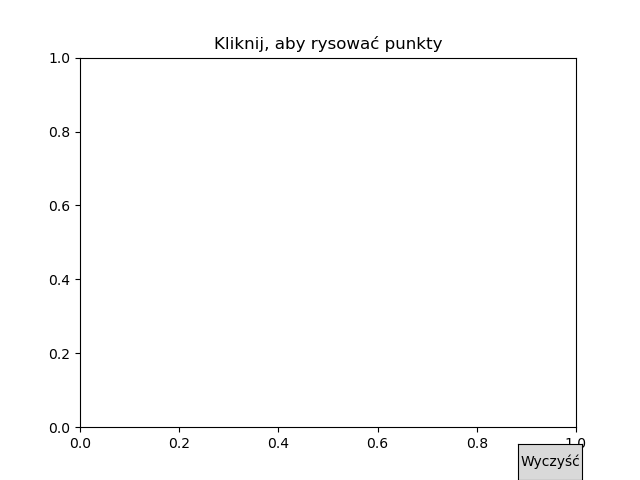

In [12]:
polygon = PolygonDrawer()

### Alogrytm Chan'a - wersja z wizualizacją algorytmu

In [13]:
def chan_visual(points):
    visualizer = ConvexHullVisualizer()
    t = 1
    n = len(points)

    while True:
        m = min(2**t, n)
        divided_points = divide_all_points(points, m)
        active_hulls = []

        L = PartialHull_visual(points, m, visualizer, active_hulls)
        if len(L) != 0:
            visualizer.add_frame(points, [L], [], [], None)
            break
        t += 1
    visualizer.add_frame(points, [], [L + [L[0]]], [], None)
    display(visualizer.create_animation())


def PartialHull_visual(points, m, visualizer, active_hulls):
    divided_points = divide_all_points(points, m)
    n = len(points)
    r = math.ceil(n / m)

    hulls = []
    final_hull = []

    for subset in divided_points:
        if len(subset) >= 3:
            local_hull = graham_algorithm(subset)
        else:
            local_hull = subset
        hulls.append(local_hull)
        active_hulls.append(local_hull)
    visualizer.add_frame(points, active_hulls.copy(), [final_hull], [], None)

    hull_nr, i = find_lowest_point(hulls)
    p1 = hulls[hull_nr][i]
    final_hull.append(p1)
    next_point = (hull_nr, i)
    active_hulls.append(final_hull)
    visualizer.add_frame(points, active_hulls.copy(), [final_hull], [], p1)

    for k in range(m):
        p = final_hull[-1]
        next_point = (next_point[0], (next_point[1] + 1) % len(hulls[next_point[0]]))
        visualizer.add_frame(points, active_hulls.copy(), [final_hull], [], hulls[next_point[0]][next_point[1]])

        for i in range(r):
            if i != next_point[0]:
                s = find_next_point_in_hull(hulls[i], p)
                q, z = hulls[next_point[0]][next_point[1]], hulls[i][s]
                t = orient(p, q, z)
                if t == -1 or t == 0 and points_distance(p, z) > points_distance(p, q):
                    next_point = (i, s)

                visualizer.add_frame(points, active_hulls.copy(), [final_hull], [Segment(final_hull[-1], z)], z)

        visualizer.add_frame(points, active_hulls.copy(), [final_hull], [Segment(final_hull[-1], hulls[next_point[0]][next_point[1]])], hulls[next_point[0]][next_point[1]])

        if hulls[next_point[0]][next_point[1]] == p1:
            return final_hull
        final_hull.append(hulls[next_point[0]][next_point[1]])
        active_hulls[-1] = final_hull.copy() 
        visualizer.add_frame(points, active_hulls.copy(), [final_hull], [], hulls[next_point[0]][next_point[1]])

    return []

def chan_with_m_visual(points, m):
    visualizer = ConvexHullVisualizer()

    divided_points = divide_all_points(points, m)
    active_hulls = []

    for subset in divided_points:
        if len(subset) >= 3:
            hull = graham_algorithm(subset)
        else:
            hull = subset
        active_hulls.append(hull)
    visualizer.add_frame(points, active_hulls.copy(), [], [], None)

    L = PartialHull_visual(points, m, visualizer, active_hulls)
    if len(L) != 0:
        visualizer.add_frame(points, [L], [], [], None)
        visualizer.add_frame(points, [], [L + [L[0]]], [], None)
    else:
        visualizer.add_frame(points, [], [], [], None)
    display(visualizer.create_animation())

Wizualizacja algorytmu Chan'a bez aproksymacji liczby punktów w otoczce

In [14]:
chan_visual(polygon.points)

Exception ignored in: <function WeakMethod.__new__.<locals>._cb at 0x00000254ADF13C40>
Traceback (most recent call last):
  File "d:\Program Files\anaconda\Lib\weakref.py", line 57, in _cb
    if self._alive:
       ^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute '_alive'


Wizualizacja algorytmu Chan'a z aproksymacji liczby punktów w otoczce

In [15]:
chan_with_m_visual(polygon.points, 4)